# 01: AlphaEarth Embeddings 抽出

Earth Engine API を使って AlphaEarth Foundations Satellite Embeddings を抽出し、npz ファイルに保存する。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aef.config import EMBEDDINGS_DIR, EXAMPLE_AOIS
from aef.ee_client import init_ee, get_embedding_at_point, get_embeddings_for_aoi

In [2]:
# Earth Engine 認証・初期化
init_ee()

## 単一点の embedding 取得

In [3]:
# 北海道農地の単一点
aoi = EXAMPLE_AOIS["hokkaido_farmland"]
emb = get_embedding_at_point(aoi["lon"], aoi["lat"], year=2023)
print(f"Shape: {emb.shape}")
print(f"Norm: {np.linalg.norm(emb):.4f}")
print(f"First 10 values: {emb[:10]}")

Shape: (64,)
Norm: 1.0020
First 10 values: [ 0.04484429  0.02712803  0.1417301  -0.09356401  0.02220684 -0.22889657
 -0.13588619  0.42377546  0.17937717  0.17937717]


## AOI の embedding 抽出

北海道農地周辺の ~5km×5km 領域を抽出する。

In [4]:
# ~5km x 5km bbox around Hokkaido farmland
center_lon, center_lat = 143.2, 43.3
half_deg = 0.025  # ~2.5km at this latitude
bbox = (center_lon - half_deg, center_lat - half_deg,
        center_lon + half_deg, center_lat + half_deg)

print(f"Extracting embeddings for bbox: {bbox}")
embeddings, coords = get_embeddings_for_aoi(bbox, year=2023, scale=100)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Coords shape: {coords.shape}")

Extracting embeddings for bbox: (143.17499999999998, 43.275, 143.225, 43.324999999999996)
Embeddings shape: (3249, 64)
Coords shape: (3249, 2)


## 保存

In [5]:
out_path = EMBEDDINGS_DIR / "hokkaido_farmland_2023.npz"
np.savez_compressed(
    out_path,
    embeddings=embeddings,
    coords=coords,
    bbox=np.array(bbox),
    year=2023,
)
print(f"Saved to {out_path.relative_to(out_path.parents[2])} ({out_path.stat().st_size / 1024:.1f} KB)")

Saved to data/embeddings/hokkaido_farmland_2023.npz (260.2 KB)


## 基本統計・分布確認

Num vectors: 3249
Norm - mean: 1.0001, std: 0.0020, min: 0.9935, max: 1.0069


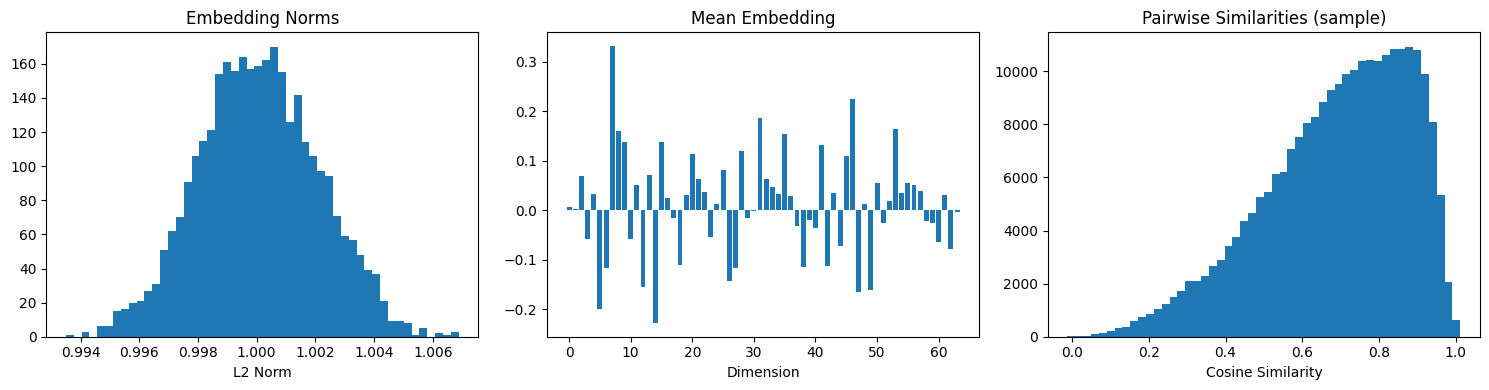

In [6]:
norms = np.linalg.norm(embeddings, axis=1)
print(f"Num vectors: {len(embeddings)}")
print(f"Norm - mean: {norms.mean():.4f}, std: {norms.std():.4f}, min: {norms.min():.4f}, max: {norms.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Norm distribution
axes[0].hist(norms, bins=50)
axes[0].set_title("Embedding Norms")
axes[0].set_xlabel("L2 Norm")

# Mean embedding
mean_emb = embeddings.mean(axis=0)
axes[1].bar(range(64), mean_emb)
axes[1].set_title("Mean Embedding")
axes[1].set_xlabel("Dimension")

# Pairwise similarity sample
sample_idx = np.random.choice(len(embeddings), min(500, len(embeddings)), replace=False)
sample = embeddings[sample_idx]
sims = (sample @ sample.T).ravel()
axes[2].hist(sims, bins=50)
axes[2].set_title("Pairwise Similarities (sample)")
axes[2].set_xlabel("Cosine Similarity")

plt.tight_layout()
plt.show()